# Preliminary Analysis for TriDENT

## Aims/Scope
- Sanity check: Does TriDENT work the way we think it does. This includes checking for the distributions of pre- and post-activations and verfifying if the samples are drawn properly.
- Additionally, does this give rise to the sigmoidal CDF that is noise dependent.
- How do simple models train under varying levels of SNR.
- Do models trained at a given SNR, also perform well under a larger (or smaller) SNR.
- How does additive noise affect the sparsity of hidden layer.

## Specific Plots:
<font color="yellow"> This list should be updated as new plots are added</font>
- Distributions showing the activations and pre-activations (v1 has these plots!)
- SNR vs. test performance plots
- SNR vs. sparsity plots
- More plots as required...

## Data Locations
- Data should be loaded from `/local_disk/vikrant/trident/models/snr_sweep*` pickle files.
- Script generating this data is in `/tests/snr_vs_perf_ffn_trident.py`.

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')

today = date.today().isoformat()



In [2]:
# Path for loading the models: UPDATE BASED ON MACHINE
MODEL_PATH = "/local_disk/vikrant/trident/models"
FIGURES_PATH = "../plots/"
DATA_PATH = "/local_disk/vikrant/trident/logs"

In [3]:
## prediction function
def pred_step(
        model: FFN, 
        inputs: jax.Array,
        labels: jax.Array,
        # metrics: nnx.MultiMetric
    ):

    logits = model(inputs)
    # print(logits)
    logits = nnx.softmax(logits, axis=-1)
    prediction = jnp.argmax(logits, axis=-1)
    # print(prediction)
    # accuracy = -1
    accuracy = jnp.mean(prediction == labels)

    return accuracy, prediction

In [4]:
# plotting the snr vs perforamnce plots
snr_models = glob.glob(os.path.join(MODEL_PATH, "snr_sweep*"))
print(snr_models)

['/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_0.0010.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_0.0100.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_0.1000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_1.0000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_10.0000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_100.0000.pkl', '/local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_1000.0000.pkl']


In [5]:
test_model = snr_models[0]
test_model = pickle.load(open(test_model, "rb"))
print(test_model['configs'])
print(test_model['data'])
print(test_model['state'])

{'train_steps': 30000, 'eval_every': 1000, 'learning_rate': 0.0001, 'threshold': 0.0, 'noise_std_arr': Array([1.00000005e-03, 9.99999978e-03, 1.00000024e-01, 1.00000000e+00,
       1.00000000e+01, 1.00000000e+02, 1.00000000e+03], dtype=float32), 'layers': [4, 32, 3], 'seed': 0}
defaultdict(<class 'list'>, {'noise_std': Array(0.001, dtype=float32), 'training_snr': [55.777183532714844], 'training_sparsity': [0.0]})
State({
  'activation': {
    'noise_std': Array(0.001, dtype=float32),
    'rngs': {
      'activation': {
        'count': RngCount( # 1 (4 B)
          value=Array(30030, dtype=uint32),
          tag='activation'
        ),
        'key': RngKey( # 1 (8 B)
          value=Array((), dtype=key<fry>) overlaying:
          [0 2],
          tag='activation'
        )
      },
      'dropout': {
        'count': RngCount( # 1 (4 B)
          value=Array(0, dtype=uint32),
          tag='dropout'
        ),
        'key': RngKey( # 1 (8 B)
          value=Array((), dtype=key<fry>) 

## Calculate RMS of the signal/preactivations on entire dataset

Size of training data (0, 4), size of test data (150, 4)
Processing model: /local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_0.0010.pkl | Models left: 1/7
Processing model: /local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_0.0100.pkl | Models left: 2/7
Processing model: /local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_0.1000.pkl | Models left: 3/7
Processing model: /local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_1.0000.pkl | Models left: 4/7
Processing model: /local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_10.0000.pkl | Models left: 5/7
Processing model: /local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_100.0000.pkl | Models left: 6/7
Processing model: /local_disk/vikrant/trident/models/snr_sweep_iris_2026-05-08_noise_1000.0000.pkl | Models left: 7/7


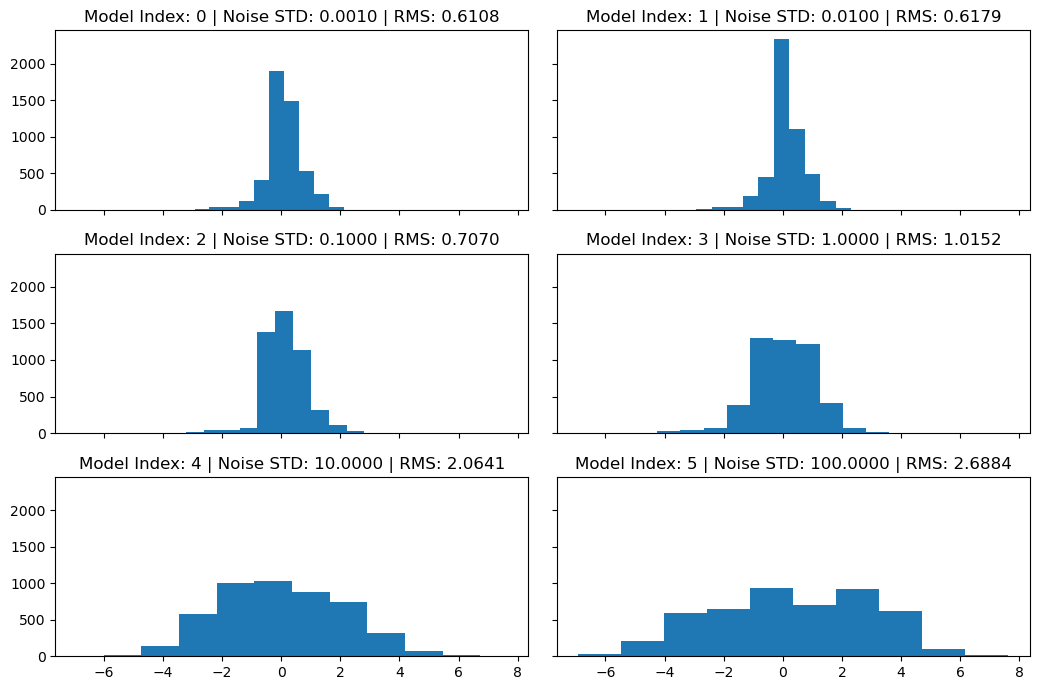

In [6]:
# load the data: seed=101, split=0.7
_, X_test, _, y_test = load_uci_iris(normalize=True, key=101, train_test_split=0.0)

# datastructures to store the results: model_name, model_index, rms_pre_activation
model_snr_dict = defaultdict(list)

# iterate over the models
for model_idx, model_name in enumerate(snr_models):
    print(f"Processing model: {model_name} | Models left: {model_idx+1}/{len(snr_models)}")

    payload = pickle.load(open(model_name, "rb"))
    model_state = payload['state']
    model_configs = payload['configs']
    model_data = payload['data']

    seed = model_configs['seed']
    rngs = nnx.Rngs(
            params=model_configs['seed'] + 0,
            dropout=model_configs['seed'] + 1,
            activation=model_configs['seed'] + 2,
        )

    # load the model
    linear_model = FFN(
                layers=model_configs['layers'],
                noise_std=model_data['noise_std'], # no noise for inference
                threshold=model_configs['threshold'],
                ActivationFunction=CustomLinear,
                rngs=rngs # rngs are initialized with the seed
            )
    
    graphdef_l, _ = nnx.split(linear_model)
    linear_model = nnx.merge(graphdef_l, model_state)

    # parse the preactivations
    preactivations = linear_model.activation(linear_model.layers[0](X_test))

    # collapse the preactivations and compjute the rms for the layer
    preactivations = preactivations.reshape(-1)
    rms_preactivation = jnp.sqrt(jnp.mean(preactivations**2))

    # append the details to the dictionary
    model_snr_dict['model_name'].append(model_name)
    model_snr_dict['model_index'].append(model_idx)
    model_snr_dict['rms_preactivation'].append(rms_preactivation.item())
    model_snr_dict['preacts'].append(preactivations.tolist())
    model_snr_dict['noise_std'].append(model_data['noise_std'].item())


# save the dictionary as pkl
save_data = False
if save_data:
    fname = f"models_preactivations_rms_{today}.pkl"

    with open(os.path.join(DATA_PATH, fname), "wb") as f:
        pickle.dump(model_snr_dict, f)

## plot the distributions
fig, ax = plt.subplots(3, 2, figsize=(10.5, 7), sharex=True, sharey=True)
for axs, m in zip(ax.ravel(), model_snr_dict['model_index']):
    axs.hist(model_snr_dict['preacts'][m])
    axs.set_title(f"Model Index: {m} | Noise STD: {model_snr_dict['noise_std'][m]:.4f} | RMS: {model_snr_dict['rms_preactivation'][m]:.4f}")
plt.tight_layout()

In [ ]:
# load the data as it was during training to preserve inference on the test set only
_, X_test, _, y_test = load_uci_iris(normalize=True, key=101, train_test_split=0.7)

# setting up sweep for noise
noise_std_arr = jnp.logspace(-4, 4, 50)

# load the model_preactivations_rms data
model_preact_data = pickle.load(open(os.path.join(DATA_PATH, "models_preactivations_rms_2026-05-12.pkl"), "rb"))

# number of noise resamples
num_resamples = 30

# store the metrics in a dictionary
metrics_dict = defaultdict(list)

    
# for loop over the model
for model_idx, model in tqdm(enumerate(snr_models), total=len(snr_models)):
    assert model_preact_data['model_name'][model_idx] == model, f"Model name mismatch: {model_preact_data['model_name'][model_idx]} vs {model}"

    # load the model
    # print(f"Model under test: {model} | models tested so far: {model_idx}/{len(snr_models)}")
    rms_preact = model_preact_data['rms_preactivation'][model_idx]
    

    payload = pickle.load(open(model, "rb"))
    model_state = payload['state']
    model_data = payload['data']
    model_configs = payload['configs']


    # for loop over noise/snr
    for noise_idx, noise_std in enumerate(noise_std_arr):
        # print(jnp.array(noise_std))

        # for loop for resampling
        for r in range(num_resamples):

            seed = model_configs['seed']
            rngs = nnx.Rngs(
                params=model_configs['seed'] + 0,
                dropout=model_configs['seed'] + 1,
                activation=model_configs['seed'] + 2,
                )
    
            # load the model states
            trident_model = FFN(
                layers=model_configs['layers'],
                noise_std=noise_std,
                threshold=model_configs['threshold'],
                ActivationFunction=DualSampleTernary,
                rngs=rngs
            )

            graphdef_t, _ = nnx.split(trident_model)
            trident_model = nnx.merge(graphdef_t, model_state)

            # compute model accuracy
            accuracy, preds = pred_step(trident_model, X_test, y_test)

            # compute activations
            hl_activations = trident_model.activation(trident_model.layers[0](X_test))
            sparsity = jnp.mean(hl_activations == 0.0)
            snr = 20*jnp.log10(rms_preact/noise_std)


            # append everything to the dictionary
            metrics_dict['accuracy'].append(accuracy.item())
            metrics_dict['sparsity'].append(sparsity.item())
            metrics_dict['snr'].append(snr.item())
            metrics_dict['noise_std'].append(noise_std.item())
            metrics_dict['model_index'].append(model_idx)
            metrics_dict['resample_index'].append(r)

            if r == num_resamples-1:
                print(f"Training Noise: {model_data['noise_std'].item()} | Avg. accuracy: {sum(metrics_dict['accuracy'][-num_resamples:])/num_resamples:.4f} | Avg sparsity: {sum(metrics_dict['sparsity'][-num_resamples:])/num_resamples:.4f} | SNR: {snr:.4f}")


# at the end of each resample, print the metrics for the last noise level
# print(f"Model Index: {model_idx} | Noise STD: {noise_std:.4f} | Accuracy: {accuracy:.4f} | Sparsity: {sparsity:.4f} | SNR: {snr:.4f}")

# optional save the metrics dictionary as pkl
save_metrics = True
if save_metrics:
    fname = f"PILOT_snr_sweep_uci_iris_{today}.pkl"

    with open(os.path.join(DATA_PATH, fname), "wb") as f:
        pickle.dump(metrics_dict, f)

print(metrics_dict)

In [13]:
mean([1, 2, 3])

NameError: name 'mean' is not defined